In [61]:
%load_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
from coffea import util
from coffea.processor import accumulate
import os
import re
import pandas as pd
import hist
import matplotlib as mpl
import mplhep
import sys
import hist
import hist.intervals

sys.path.append("../analysisTools/")
import plotTools as ptools
import utils

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [62]:
#coffea output file
f_sig = "../coffea/corrected_sig_2022/WithXclean.coffea"  #sample that includes the x-clean loop

#Nested Dictionary:
sig_histo = util.load(f_sig) [0]
# print (sig_histo)

Saved: ./plots/signal_2018/gen_ele_vxy10_m110.png
counts_nonzero_den: [ nan 178. 654. 702. 545. 448. 341. 235. 170. 108.  66.  45.  35.  20.
  16.  13.   9.   2.   8.   4.   2.   2.  nan  nan  nan  nan  nan   1.
  nan  nan]
edges_nonzero_den: [ nan  1.5  2.5  3.5  4.5  5.5  6.5  7.5  8.5  9.5 10.5 11.5 12.5 13.5
 14.5 15.5 16.5 17.5 18.5 19.5 20.5 21.5  nan  nan  nan  nan  nan 27.5
  nan  nan]


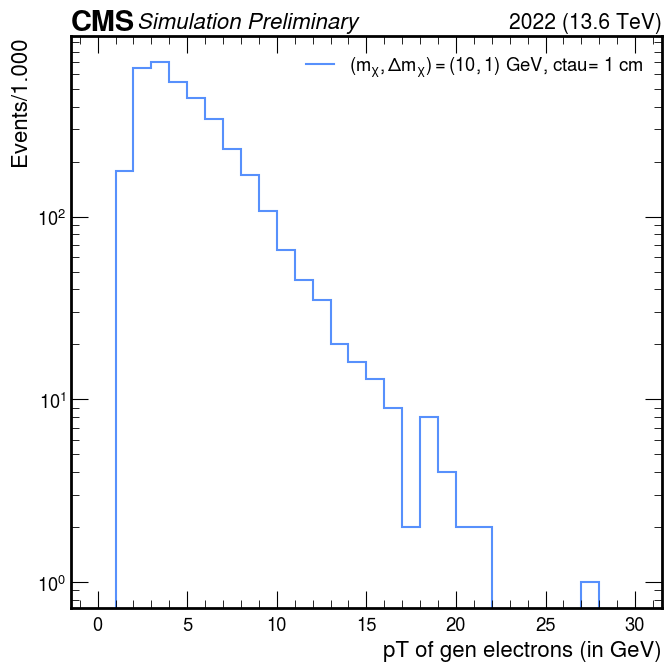

In [63]:
#Denominator
fig, ax = plt.subplots(figsize=(7,7))

delta =0.1
ctau =10

# Plot settings
plot_dict = {
    'variable':'gen_ele_pt',
    'cut': 'cut0',
    'year': 2022
}

style_dict = {
    'fig': fig,
    'ax': ax,
    'rebin': None,
    'xlim': None,     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]
    'doLogy': True, 
    'doLogx': False,
    'doDensity': False,
    'doYerr': False, 
    'xlabel': "pT of gen electrons (in GeV)",   # if None, the default will show up; otherwise give as a string, i.e. 'Electron dxy'
    'ylabel': None,   # if None, the default will show up; otherwise give as a string, i.e. 'Efficiency'
    'label': None,    # if None, the default will show up; otherwise give as a string, i.e. 'Highest ctau signal samples'
    'flow': None,     # overflow
    'doSave': True,
    'outDir': './plots/signal_2018',
    'outName': f'gen_ele_vxy10_m110.png'
}



#signal points
m1 = 10
delta =0.1
ctau =10

# ptools.plot_signal_1D(sig_histo, m1, delta, ctau, plot_dict, style_dict)

counts, edges = ptools.plot_signal_1D_match(
        sig_histo, m1, delta, ctau,
        plot_dict, style_dict,
        match_type='R', passID=1
    )


counts = np.array(counts)     # shape: (n_m1, n_bins)
edges  = np.array(edges)      # shape: (n_m1, n_edges)

# print ("edges:", edges)
# print (counts)

mask = counts != 0

bins_x = (edges[:-1] + edges[1:])*(0.5)
# print ("bins_x:",bins_x)

counts_nonzero_den = np.where(mask, counts, np.nan)
edges_nonzero_den  = np.where(mask, bins_x, np.nan)

print ("counts_nonzero_den:",counts_nonzero_den)
print ("edges_nonzero_den:", edges_nonzero_den)

Saved: ./plots/signal_2018/match_ele_gen_vxy10_m110.png
[ 0.5  1.5  2.5  3.5  4.5  5.5  6.5  7.5  8.5  9.5 10.5 11.5 12.5 13.5
 14.5 15.5 16.5 17.5 18.5 19.5 20.5 21.5 22.5 23.5 24.5 25.5 26.5 27.5
 28.5 29.5]
[  0. 177. 654. 700. 537. 386. 269. 186. 129.  83.  49.  39.  28.  20.
  12.  10.   7.   1.   7.   3.   1.   2.   0.   0.   0.   0.   0.   1.
   0.   0.]


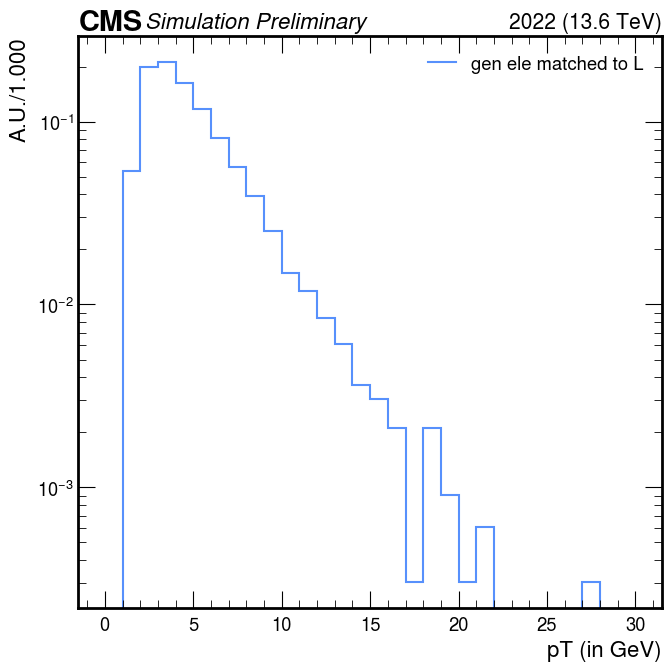

In [64]:
#Low-pT match
fig, ax = plt.subplots(figsize=(7,7))


plot_dict = {'variable': 'match_ele_gen_pt', 'cut': 'cut0', 'year': 2022}

style_dict = {
    'fig': fig,
    'ax': ax,
    'rebin': None,
    'xlim': None,     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]
    'doLogy': True, 
    'doLogx': False,
    'doDensity': True,
    'doYerr': False, 
    #'xlabel': "pT of gen electrons(matched to 'R')",  
    'xlabel': "pT (in GeV)",              # if None, the default will show up; otherwise give as a string, i.e. 'Electron dxy'
    'ylabel': None,   # if None, the default will show up; otherwise give as a string, i.e. 'Efficiency'
    'label': "gen ele matched to L"  ,    # if None, the default will show up; otherwise give as a string, i.e. 'Highest ctau signal samples'
    'flow': None,     # overflow
    'doSave': True,
    'outDir': './plots/signal_2018',
    'outName': f'match_ele_gen_vxy10_m110.png'
}
m1 = 10
delta = 0.1
ctau = 10

countsn, edgesn=ptools.plot_signal_1D_match(
        sig_histo, m1, delta, ctau,
        plot_dict, style_dict,
        match_type='L', passID=1
    )

counts_num_L = np.array(countsn)     # shape: (n_m1, n_bins)
edges_num  = np.array(edgesn)      # shape: (n_m1, n_edges)

bins_x_num = (edges_num[:-1] + edges_num[1:])*(0.5)

print (bins_x_num)
print (counts_num_L)

Saved: ./plots/signal_2018/match_ele_gen_vxy10_m110.png
[ 0.5  1.5  2.5  3.5  4.5  5.5  6.5  7.5  8.5  9.5 10.5 11.5 12.5 13.5
 14.5 15.5 16.5 17.5 18.5 19.5 20.5 21.5 22.5 23.5 24.5 25.5 26.5 27.5
 28.5 29.5]
[ 0.  1.  0.  2.  8. 62. 72. 49. 41. 25. 17.  6.  7.  0.  4.  3.  2.  1.
  1.  1.  1.  0.  0.  0.  0.  0.  0.  0.  0.  0.]


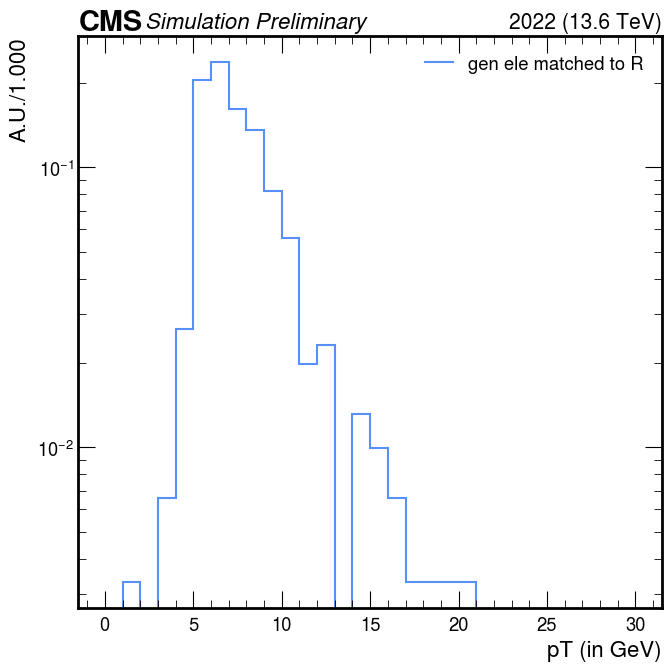

In [65]:
#R match
fig, ax = plt.subplots(figsize=(7,7))


plot_dict = {'variable': 'match_ele_gen_pt', 'cut': 'cut0', 'year': 2022}

style_dict = {
    'fig': fig,
    'ax': ax,
    'rebin': None,
    'xlim': None,     # if None, the default will show up; otherwise give as a list, i.e. [0, 10]
    'doLogy': True, 
    'doLogx': False,
    'doDensity': True,
    'doYerr': False, 
    #'xlabel': "pT of gen electrons(matched to 'R')",  
    'xlabel': "pT (in GeV)",              # if None, the default will show up; otherwise give as a string, i.e. 'Electron dxy'
    'ylabel': None,   # if None, the default will show up; otherwise give as a string, i.e. 'Efficiency'
    'label': "gen ele matched to R"  ,    # if None, the default will show up; otherwise give as a string, i.e. 'Highest ctau signal samples'
    'flow': None,     # overflow
    'doSave': True,
    'outDir': './plots/signal_2018',
    'outName': f'match_ele_gen_vxy10_m110.png'
}
m1 = 10
delta = 0.1
ctau = 10

countsnn, edgesnn=ptools.plot_signal_1D_match(
        sig_histo, m1, delta, ctau,
        plot_dict, style_dict,
        match_type='R', passID=1
    )

counts_num_R = np.array(countsnn)     # shape: (n_m1, n_bins)
edges_numnn  = np.array(edgesnn)      # shape: (n_m1, n_edges)

bins_x_numnn = (edges_numnn[:-1] + edges_numnn[1:])*(0.5)

print (bins_x_numnn)
print (counts_num_R)

In [66]:
num = counts_num_R + counts_num_L

In [67]:
def eff_determine_unc(n, d):
    eff = np.divide(n, d)
    unc = hist.intervals.ratio_uncertainty(n, d, 'efficiency')
    return eff, unc


efficiency_R, unc_eff_R = eff_determine_unc(num, counts_nonzero_den)
print ("efficiency_R:",efficiency_R)
print ("unc_eff_R:", unc_eff_R)

efficiency_R: [nan  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.  1.
  1.  1.  1.  1. nan nan nan nan nan  1. nan nan]
unc_eff_R: [[       nan 0.01028952 0.00281106 0.0026191  0.00337232 0.00410099
  0.00538434 0.00780353 0.01077111 0.01690203 0.02750881 0.04008601
  0.05124115 0.08794144 0.10869077 0.13204642 0.1849925  0.60168448
  0.20556786 0.36887757 0.60168448 0.60168448        nan        nan
         nan        nan        nan 0.84134475        nan        nan]
 [       nan 0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.                nan        nan
         nan        nan        nan 0.                nan        nan]]


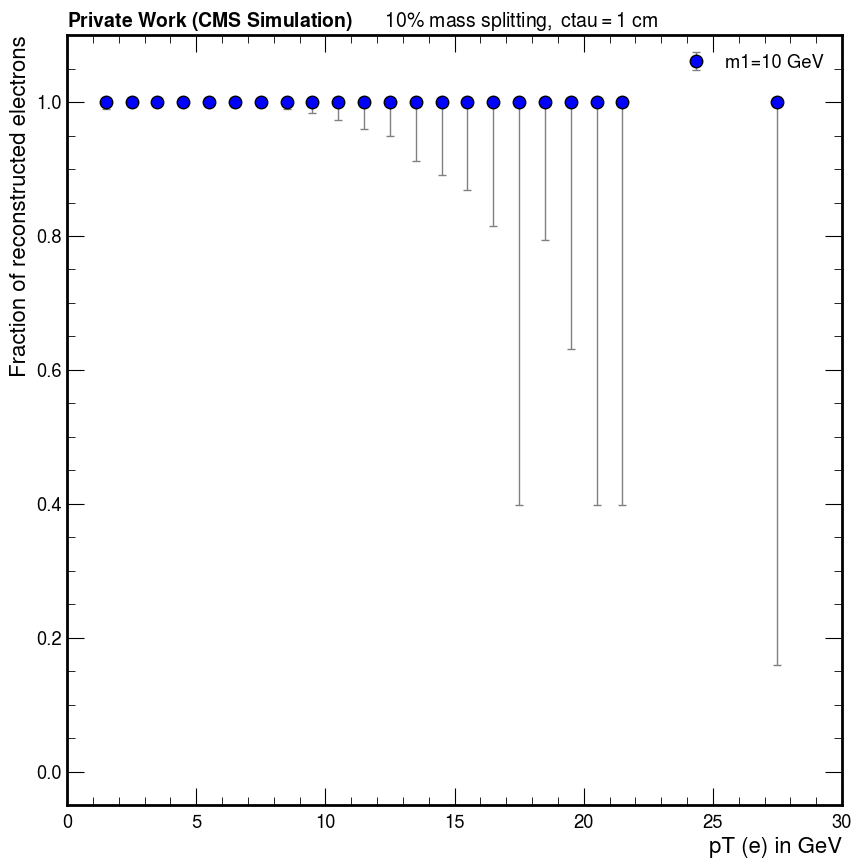

In [68]:
plt.errorbar(
    bins_x_numnn, efficiency_R,
    yerr=unc_eff_R ,fmt='o', markersize=9, markerfacecolor='blue', markeredgecolor='black',
    ecolor='gray', elinewidth=1, capsize=3,
    label='m1=10 GeV'  
)

plt.xlim(0,30)
plt.ylim(-0.05,1.1)
plt.xlabel("pT (e) in GeV")
plt.ylabel("Fraction of reconstructed electrons")

plt.title(r"$\bf{Private\ Work\ (CMS\ Simulation)} \qquad \mathrm{10\% \ mass\ splitting,\ ctau = 1\ cm}$",
          fontsize=14, loc='left')



plt.legend(loc='upper right')
plt.savefig("L_cuts_ERE.png", dpi=300)
